In [1]:
# SIT720 11.1HD
# Reproduction of:
# "An efficient stacking-based ensemble technique for early heart attack prediction"

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Environment Ready")

Environment Ready


In [2]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart.csv


In [3]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(1025, 14)

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [6]:
print("Duplicate Rows:")
df.duplicated().sum()

Duplicate Rows:


np.int64(723)

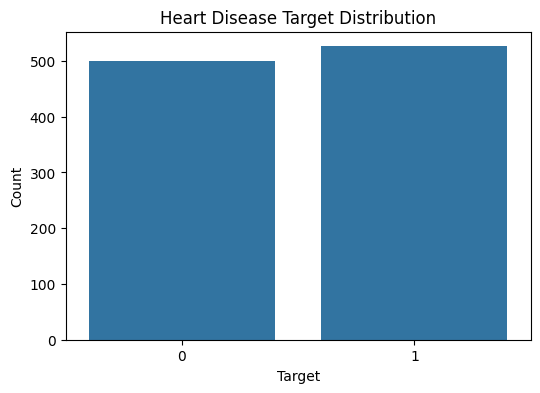

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="target"
)

plt.title("Heart Disease Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
# Duplicate analysis

duplicate_count = df.duplicated().sum()
total_rows = len(df)

duplicate_percentage = (duplicate_count / total_rows) * 100

print("Total records:", total_rows)
print("Duplicate records:", duplicate_count)
print("Duplicate percentage: {:.2f}%".format(duplicate_percentage))

Total records: 1025
Duplicate records: 723
Duplicate percentage: 70.54%


In [10]:
# Create a copy for preprocessing experiments

df_clean = df.drop_duplicates()

print("Original dataset shape:", df.shape)
print("After removing duplicates:", df_clean.shape)

Original dataset shape: (1025, 14)
After removing duplicates: (302, 14)


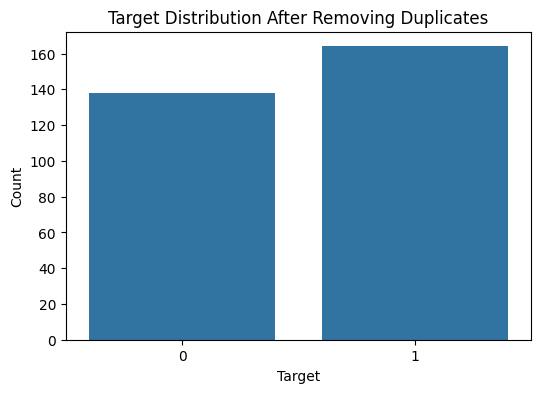

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_clean,
    x="target"
)

plt.title("Target Distribution After Removing Duplicates")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

In [12]:
# Feature and target separation

X = df.drop("target", axis=1)
y = df["target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1025, 13)
Target shape: (1025,)


In [13]:
# Check feature data types

X.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [14]:
# Categorical features based on dataset description

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]


numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]


print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

Numerical features:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


In [15]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)


print("Preprocessor created successfully")

Preprocessor created successfully


In [16]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


print("Scaled feature shape:", X_scaled.shape)

Scaled feature shape: (1025, 13)


In [17]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.268437,0.661504,-0.915755,-0.377636,-0.659332,-0.418878,0.891255,0.821321,-0.712287,-0.060888,0.995433,1.209221,1.089852
1,-0.158157,0.661504,-0.915755,0.479107,-0.833861,2.387330,-1.004049,0.255968,1.403928,1.727137,-2.243675,-0.731971,1.089852
2,1.716595,0.661504,-0.915755,0.764688,-1.396233,-0.418878,0.891255,-1.048692,1.403928,1.301417,-2.243675,-0.731971,1.089852
3,0.724079,0.661504,-0.915755,0.936037,-0.833861,-0.418878,0.891255,0.516900,-0.712287,-0.912329,0.995433,0.238625,1.089852
4,0.834359,-1.511706,-0.915755,0.364875,0.930822,2.387330,0.891255,-1.874977,-0.712287,0.705408,-0.624121,2.179817,-0.522122


In [18]:
print("Final X shape:", X_scaled_df.shape)
print("Final y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

Final X shape: (1025, 13)
Final y shape: (1025,)

Class distribution:
target
1    526
0    499
Name: count, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
# Train-test split for reproduction

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Training data shape:")
print(X_train.shape)

print("\nTesting data shape:")
print(X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data shape:
(820, 13)

Testing data shape:
(205, 13)

Training target distribution:
target
1    421
0    399
Name: count, dtype: int64

Testing target distribution:
target
1    105
0    100
Name: count, dtype: int64


In [21]:
split_summary = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Samples": [
        len(X_train),
        len(X_test)
    ]
})

split_summary

,Dataset,Samples
0,Training,820
1,Testing,205


In [22]:
# Machine Learning Libraries

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

print("ML libraries imported successfully")

ML libraries imported successfully


In [23]:
# Define individual classifiers

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "Naive Bayes": GaussianNB(),

    "KNN": KNeighborsClassifier()
}


print("Models created:")
for model in models:
    print(model)

Models created:
Logistic Regression
Decision Tree
Random Forest
XGBoost
Naive Bayes
KNN


In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)


def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    # probability prediction for AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)


    results = {

        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1 Score": f1_score(y_test, y_pred),

        "AUC": roc_auc_score(y_test, y_prob)
    }

    return results

In [25]:
# Train and evaluate individual models

baseline_results = []

trained_models = {}


for name, model in models.items():

    print(f"Training {name}...")

    # Train model
    model.fit(X_train, y_train)

    # Save trained model
    trained_models[name] = model

    # Evaluate
    result = evaluate_model(
        model,
        X_test,
        y_test
    )

    # Add model name
    result["Model"] = name

    baseline_results.append(result)


print("All models trained successfully")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training Naive Bayes...
Training KNN...
All models trained successfully


In [26]:
# Convert results into dataframe

baseline_results_df = pd.DataFrame(baseline_results)

# Rearrange columns

baseline_results_df = baseline_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ]
]


baseline_results_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.809756,0.761905,0.914286,0.831169,0.929714
1,Decision Tree,0.985366,1.000000,0.971429,0.985507,0.985714
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
3,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
4,Naive Bayes,0.829268,0.807018,0.876190,0.840183,0.904286
5,KNN,0.863415,0.873786,0.857143,0.865385,0.962571


In [27]:
baseline_results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
3,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,0.985366,1.000000,0.971429,0.985507,0.985714
5,KNN,0.863415,0.873786,0.857143,0.865385,0.962571
4,Naive Bayes,0.829268,0.807018,0.876190,0.840183,0.904286
0,Logistic Regression,0.809756,0.761905,0.914286,0.831169,0.929714


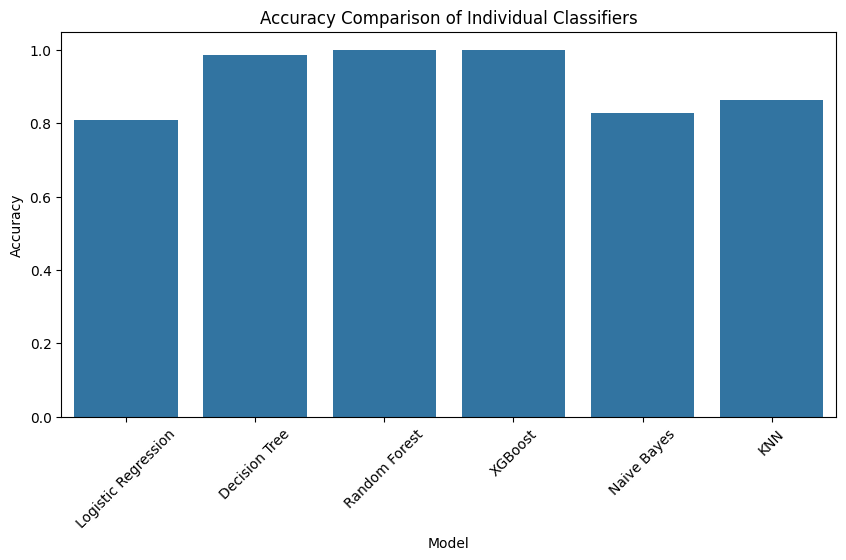

In [28]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=baseline_results_df,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=45)

plt.title(
    "Accuracy Comparison of Individual Classifiers"
)

plt.ylabel("Accuracy")

plt.show()

In [29]:
# Reload original features before scaling

X_original = df.drop("target", axis=1)
y_original = df["target"]

print("Features:", X_original.shape)
print("Target:", y_original.shape)

Features: (1025, 13)
Target: (1025,)


In [30]:
from sklearn.model_selection import train_test_split


X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_original,
    y_original,
    test_size=0.2,
    random_state=42,
    stratify=y_original
)


print("Training shape:", X_train_raw.shape)
print("Testing shape:", X_test_raw.shape)

Training shape: (820, 13)
Testing shape: (205, 13)


In [31]:
from sklearn.preprocessing import StandardScaler


scaler_correct = StandardScaler()


# Fit only on training data
X_train_scaled = scaler_correct.fit_transform(
    X_train_raw
)


# Transform test data
X_test_scaled = scaler_correct.transform(
    X_test_raw
)


print("Training scaled shape:", X_train_scaled.shape)
print("Testing scaled shape:", X_test_scaled.shape)

Training scaled shape: (820, 13)
Testing scaled shape: (205, 13)


In [32]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_original.columns
)


X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_original.columns
)


X_train_scaled.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.811626,-1.509967,-0.909572,0.314729,0.895791,2.346899,0.926946,-1.921155,-0.718131,0.696525,-0.597542,2.207301,-0.562451
1,0.152247,-1.509967,-0.909572,3.767643,0.779115,2.346899,-0.982842,-0.725362,1.392504,2.475810,-2.198799,1.228400,1.090630
2,0.262144,0.662266,1.048037,-0.242193,-0.368191,-0.426094,-0.982842,0.027545,-0.718131,-0.574393,-0.597542,0.249500,1.090630
3,0.262144,0.662266,1.048037,0.983035,-2.371116,2.346899,0.926946,1.046184,-0.718131,-0.743849,1.003715,0.249500,1.090630
4,-0.287339,-1.509967,1.048037,0.203344,-1.009905,-0.426094,-0.982842,0.869030,-0.718131,-0.828577,-0.597542,-0.729400,-0.562451


In [33]:
corrected_results = []

corrected_models = {}


for name, model in models.items():

    print(f"Training {name}...")

    model.fit(
        X_train_scaled,
        y_train
    )

    corrected_models[name] = model

    result = evaluate_model(
        model,
        X_test_scaled,
        y_test
    )

    result["Model"] = name

    corrected_results.append(result)


print("Corrected training completed")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training Naive Bayes...
Training KNN...
Corrected training completed


In [34]:
corrected_results_df = pd.DataFrame(
    corrected_results
)


corrected_results_df = corrected_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ]
]


corrected_results_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.809756,0.761905,0.914286,0.831169,0.929810
1,Decision Tree,0.985366,1.000000,0.971429,0.985507,0.985714
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
3,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
4,Naive Bayes,0.829268,0.807018,0.876190,0.840183,0.904286
5,KNN,0.863415,0.873786,0.857143,0.865385,0.962905


In [35]:
corrected_results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
3,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,0.985366,1.000000,0.971429,0.985507,0.985714
5,KNN,0.863415,0.873786,0.857143,0.865385,0.962905
4,Naive Bayes,0.829268,0.807018,0.876190,0.840183,0.904286
0,Logistic Regression,0.809756,0.761905,0.914286,0.831169,0.929810


## Experiment B — Duplicate-Free Dataset Evaluation

In [36]:
# Remove duplicate records

df_unique = df.drop_duplicates()

print("Original dataset:")
print(df.shape)

print("\nUnique dataset after removing duplicates:")
print(df_unique.shape)

Original dataset:
(1025, 14)

Unique dataset after removing duplicates:
(302, 14)


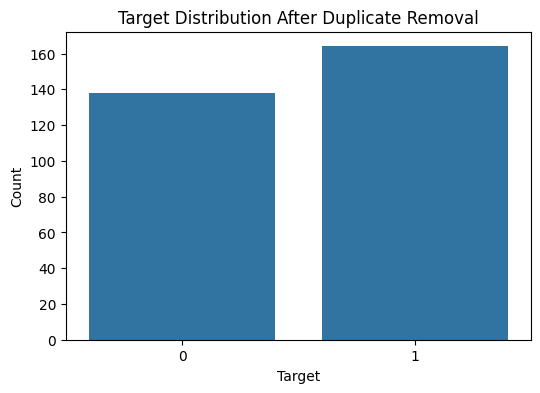

In [37]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_unique,
    x="target"
)

plt.title(
    "Target Distribution After Duplicate Removal"
)

plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

In [38]:
# Features and target for unique dataset

X_unique = df_unique.drop(
    "target",
    axis=1
)

y_unique = df_unique["target"]


print("Features:")
print(X_unique.shape)

print("\nTarget:")
print(y_unique.shape)

Features:
(302, 13)

Target:
(302,)


In [39]:
# Split unique dataset

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_unique,
    y_unique,
    test_size=0.2,
    random_state=42,
    stratify=y_unique
)


print("Training:")
print(X_train_u.shape)

print("\nTesting:")
print(X_test_u.shape)

Training:
(241, 13)

Testing:
(61, 13)


In [40]:
# Scaling without leakage

scaler_unique = StandardScaler()


X_train_u_scaled = scaler_unique.fit_transform(
    X_train_u
)


X_test_u_scaled = scaler_unique.transform(
    X_test_u
)


print(
    "Training scaled:",
    X_train_u_scaled.shape
)

print(
    "Testing scaled:",
    X_test_u_scaled.shape
)

Training scaled: (241, 13)
Testing scaled: (61, 13)


In [41]:
X_train_u_scaled = pd.DataFrame(
    X_train_u_scaled,
    columns=X_unique.columns
)


X_test_u_scaled = pd.DataFrame(
    X_test_u_scaled,
    columns=X_unique.columns
)


X_train_u_scaled.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,1.421944,-1.445595,0.986493,-0.973041,5.882908,-0.398314,-1.008059,0.408240,-0.652714,0.527263,-0.697127,-0.722716,1.075838
1,-0.465841,0.691757,-0.954281,0.756507,-0.885696,-0.398314,-1.008059,-1.104705,1.532065,-0.083233,-0.697127,-0.722716,1.075838
2,0.422528,0.691757,-0.954281,-0.197726,-0.588175,-0.398314,-1.008059,-0.882213,1.532065,1.050546,-0.697127,2.132606,1.075838
3,1.644036,0.691757,0.986493,0.517949,0.118437,-0.398314,-1.008059,-0.214737,-0.652714,0.876119,-0.697127,2.132606,1.075838
4,-1.021072,-1.445595,0.016106,-1.151959,-1.629499,-0.398314,0.875214,-0.570724,-0.652714,-0.868157,-0.697127,-0.722716,-0.544643


In [42]:
unique_results = []

unique_models = {}


for name, model in models.items():

    print(f"Training {name}...")

    model.fit(
        X_train_u_scaled,
        y_train_u
    )

    unique_models[name] = model


    result = evaluate_model(
        model,
        X_test_u_scaled,
        y_test_u
    )


    result["Model"] = name

    unique_results.append(result)


print("Unique dataset training completed")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training Naive Bayes...
Training KNN...
Unique dataset training completed


In [43]:
unique_results_df = pd.DataFrame(
    unique_results
)


unique_results_df = unique_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ]
]


unique_results_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529,0.871212
1,Decision Tree,0.803279,0.818182,0.818182,0.818182,0.801948
2,Random Forest,0.754098,0.764706,0.787879,0.776119,0.858766
3,XGBoost,0.721311,0.735294,0.757576,0.746269,0.832251
4,Naive Bayes,0.786885,0.833333,0.757576,0.793651,0.884199
5,KNN,0.786885,0.777778,0.848485,0.811594,0.837662


In [44]:
unique_results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529,0.871212
1,Decision Tree,0.803279,0.818182,0.818182,0.818182,0.801948
5,KNN,0.786885,0.777778,0.848485,0.811594,0.837662
4,Naive Bayes,0.786885,0.833333,0.757576,0.793651,0.884199
2,Random Forest,0.754098,0.764706,0.787879,0.776119,0.858766
3,XGBoost,0.721311,0.735294,0.757576,0.746269,0.832251


## Stacking Ensemble Reproduction

In [45]:
# Define base estimators for stacking

base_estimators = [

    (
        "lr",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    ),

    (
        "dt",
        DecisionTreeClassifier(
            random_state=42
        )
    ),

    (
        "rf",
        RandomForestClassifier(
            random_state=42
        )
    ),

    (
        "xgb",
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    ),

    (
        "nb",
        GaussianNB()
    ),

    (
        "knn",
        KNeighborsClassifier()
    )
]


print("Base learners created:")
for model in base_estimators:
    print(model[0])

Base learners created:
lr
dt
rf
xgb
nb
knn


In [46]:
# Stacking classifier

stacking_model = StackingClassifier(

    estimators=base_estimators,

    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    cv=5,

    n_jobs=-1
)


print("Stacking model created successfully")

Stacking model created successfully


In [47]:
# Train stacking model on original dataset

stacking_model.fit(
    X_train_scaled,
    y_train
)


print("Stacking model training completed")

Stacking model training completed


In [48]:
# Evaluate stacking model

stacking_result = evaluate_model(
    stacking_model,
    X_test_scaled,
    y_test
)


stacking_result

{'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1 Score': 1.0,
 'AUC': np.float64(1.0)}

In [49]:
# Create stacking result dataframe

stacking_results_df = pd.DataFrame(
    [stacking_result]
)


stacking_results_df["Model"] = "Stacking Ensemble"


stacking_results_df = stacking_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ]
]


stacking_results_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Stacking Ensemble,1.0,1.0,1.0,1.0,1.0


In [50]:
# Combine all baseline results

final_baseline_results = pd.concat(
    [
        corrected_results_df,
        stacking_results_df
    ],
    ignore_index=True
)


final_baseline_results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.809756,0.761905,0.914286,0.831169,0.929810
1,Decision Tree,0.985366,1.000000,0.971429,0.985507,0.985714
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
3,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
4,Naive Bayes,0.829268,0.807018,0.876190,0.840183,0.904286
5,KNN,0.863415,0.873786,0.857143,0.865385,0.962905
6,Stacking Ensemble,1.000000,1.000000,1.000000,1.000000,1.000000


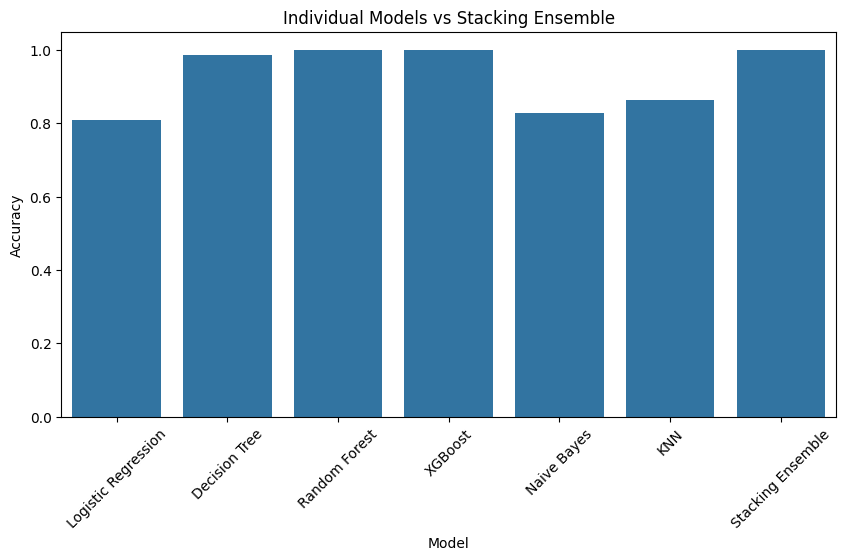

In [51]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=final_baseline_results,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=45)

plt.title(
    "Individual Models vs Stacking Ensemble"
)

plt.ylabel(
    "Accuracy"
)

plt.show()

# Experiment B — Duplicate-Free Stacking Ensemble Evaluation

## Objective

This experiment evaluates the stacking ensemble model after removing duplicate observations from the original dataset.

The original dataset contains duplicated records, which may introduce optimistic evaluation when random train-test splitting is applied. Therefore, this experiment investigates the robustness of the proposed stacking framework using only unique patient records.

## Dataset Preparation

- Original dataset size: 1025 records
- Duplicate records removed: 723
- Final unique dataset size: 302 records

## Experimental Procedure

The same stacking ensemble architecture used in Experiment A is applied:

### Base Learners
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- Naive Bayes
- K-Nearest Neighbours

### Meta Learner
- Logistic Regression

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-score
- AUC

The results will be compared with:
1. Original paper results
2. Full dataset reproduction results
3. Duplicate-free evaluation results

## B.1 Dataset Preparation and Train-Test Split

In [52]:
# Create stacking ensemble for duplicate-free dataset

stacking_model_unique = StackingClassifier(

    estimators=base_estimators,

    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    cv=5,

    n_jobs=-1
)


print("Duplicate-free stacking model created successfully")

Duplicate-free stacking model created successfully


## B.2 Model Training and Evaluation

In [53]:
# Train stacking ensemble using unique dataset

stacking_model_unique.fit(
    X_train_u_scaled,
    y_train_u
)


print("Duplicate-free stacking training completed")

Duplicate-free stacking training completed


In [54]:
# Evaluate duplicate-free stacking model

stacking_unique_result = evaluate_model(
    stacking_model_unique,
    X_test_u_scaled,
    y_test_u
)


stacking_unique_result

{'Accuracy': 0.7540983606557377,
 'Precision': 0.7647058823529411,
 'Recall': 0.7878787878787878,
 'F1 Score': 0.7761194029850746,
 'AUC': np.float64(0.8679653679653679)}

In [55]:
# Create duplicate-free stacking result table

stacking_unique_df = pd.DataFrame(
    [stacking_unique_result]
)


stacking_unique_df["Model"] = "Stacking Ensemble (Unique Dataset)"


stacking_unique_df = stacking_unique_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ]
]


stacking_unique_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Stacking Ensemble (Unique Dataset),0.754098,0.764706,0.787879,0.776119,0.867965


## B.3 Comparison of Stacking Performance

In [56]:
# Compare stacking performance

stacking_comparison = pd.DataFrame({

    "Experiment": [
        "Original Dataset (1025 Records)",
        "Duplicate-Free Dataset (302 Records)"
    ],

    "Accuracy": [
        stacking_result["Accuracy"],
        stacking_unique_result["Accuracy"]
    ],

    "Precision": [
        stacking_result["Precision"],
        stacking_unique_result["Precision"]
    ],

    "Recall": [
        stacking_result["Recall"],
        stacking_unique_result["Recall"]
    ],

    "F1 Score": [
        stacking_result["F1 Score"],
        stacking_unique_result["F1 Score"]
    ],

    "AUC": [
        stacking_result["AUC"],
        stacking_unique_result["AUC"]
    ]

})


stacking_comparison

,Experiment,Accuracy,Precision,Recall,F1 Score,AUC
0,Original Dataset (1025 Records),1.000000,1.000000,1.000000,1.000000,1.000000
1,Duplicate-Free Dataset (302 Records),0.754098,0.764706,0.787879,0.776119,0.867965


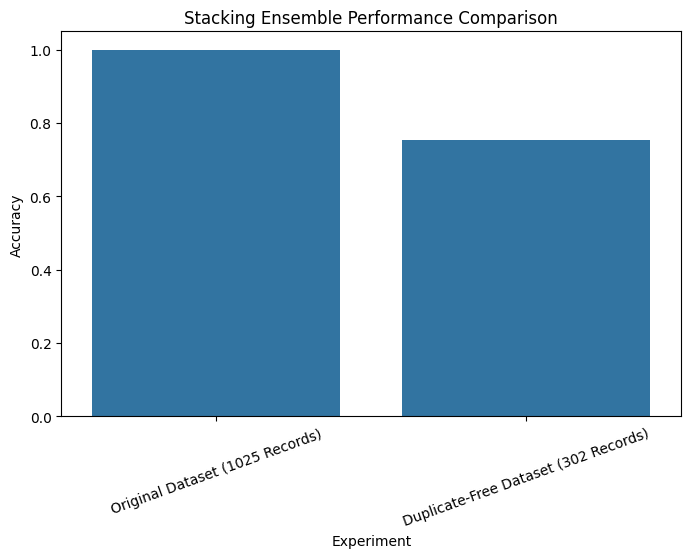

In [57]:
plt.figure(figsize=(8,5))


sns.barplot(
    data=stacking_comparison,
    x="Experiment",
    y="Accuracy"
)


plt.xticks(rotation=20)

plt.title(
    "Stacking Ensemble Performance Comparison"
)

plt.ylabel(
    "Accuracy"
)

plt.show()

# Experiment C — Proposed Improved ML Framework

## Objective

This experiment introduces an improved machine learning framework by addressing limitations identified during paper reproduction.

The proposed approach focuses on reliable evaluation, feature optimisation, model tuning, and explainability.

## C.1 Feature Importance Analysis

Feature importance analysis is performed to identify the most influential clinical attributes associated with heart disease prediction.

A Random Forest classifier is used to estimate feature importance because tree-based models can capture nonlinear relationships between predictors and the target variable.

The selected important features will be used for the proposed optimised stacking framework.

In [58]:
# Use duplicate-free dataset for proposed framework

X_proposed = df_unique.drop(
    "target",
    axis=1
)

y_proposed = df_unique["target"]


print("Feature shape:", X_proposed.shape)
print("Target shape:", y_proposed.shape)

Feature shape: (302, 13)
Target shape: (302,)


In [59]:
from sklearn.ensemble import RandomForestClassifier


rf_feature_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)


rf_feature_model.fit(
    X_proposed,
    y_proposed
)


print("Feature importance model trained")

Feature importance model trained


In [60]:
feature_importance = pd.DataFrame({

    "Feature": X_proposed.columns,

    "Importance": rf_feature_model.feature_importances_

})


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


feature_importance

,Feature,Importance
2,cp,0.128970
7,thalach,0.127492
12,thal,0.115957
11,ca,0.114378
9,oldpeak,0.106026
0,age,0.089453
4,chol,0.075828
3,trestbps,0.071096
8,exang,0.056356
10,slope,0.047484


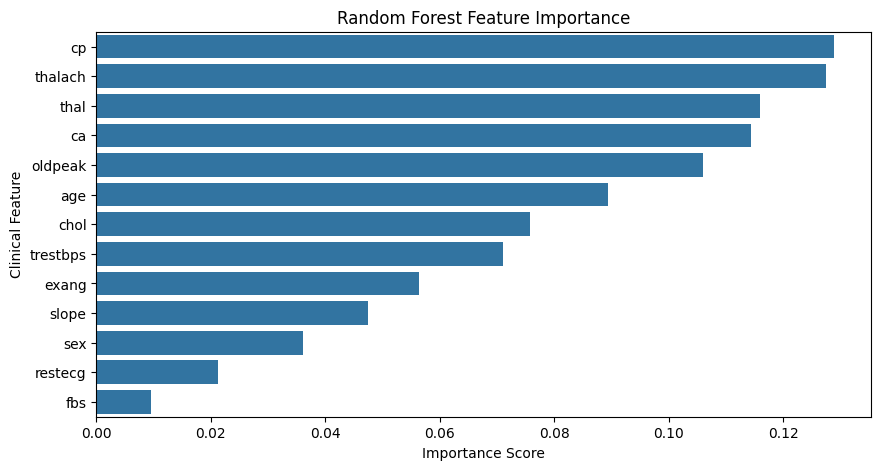

In [61]:
plt.figure(figsize=(10,5))


sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)


plt.title(
    "Random Forest Feature Importance"
)


plt.xlabel(
    "Importance Score"
)


plt.ylabel(
    "Clinical Feature"
)


plt.show()

## C.2 Feature Selection

Based on the Random Forest feature importance analysis, the ten highest-ranked clinical features were selected for the proposed framework.

Feature selection is applied to reduce less informative variables while preserving the major clinical indicators associated with heart disease prediction.

Selected features:

- cp
- thalach
- thal
- ca
- oldpeak
- age
- chol
- trestbps
- exang
- slope

In [62]:
# Select top 10 important features

selected_features = [
    "cp",
    "thalach",
    "thal",
    "ca",
    "oldpeak",
    "age",
    "chol",
    "trestbps",
    "exang",
    "slope"
]


X_selected = df_unique[selected_features]

y_selected = df_unique["target"]


print("Selected feature shape:")
print(X_selected.shape)


print("\nSelected features:")
print(X_selected.columns.tolist())

Selected feature shape:
(302, 10)

Selected features:
['cp', 'thalach', 'thal', 'ca', 'oldpeak', 'age', 'chol', 'trestbps', 'exang', 'slope']


In [63]:
# Split selected feature dataset

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected,
    y_selected,
    test_size=0.2,
    random_state=42,
    stratify=y_selected
)


print("Training shape:")
print(X_train_sel.shape)


print("\nTesting shape:")
print(X_test_sel.shape)

Training shape:
(241, 10)

Testing shape:
(61, 10)


In [64]:
# Scale selected features without leakage

scaler_selected = StandardScaler()


X_train_sel_scaled = scaler_selected.fit_transform(
    X_train_sel
)


X_test_sel_scaled = scaler_selected.transform(
    X_test_sel
)


print(
    "Training scaled:",
    X_train_sel_scaled.shape
)


print(
    "Testing scaled:",
    X_test_sel_scaled.shape
)

Training scaled: (241, 10)
Testing scaled: (61, 10)


In [65]:
# Convert scaled selected features back to dataframe

X_train_sel_scaled = pd.DataFrame(
    X_train_sel_scaled,
    columns=selected_features
)


X_test_sel_scaled = pd.DataFrame(
    X_test_sel_scaled,
    columns=selected_features
)


X_train_sel_scaled.head()

,cp,thalach,thal,ca,oldpeak,age,chol,trestbps,exang,slope
0,0.986493,0.408240,1.075838,-0.722716,0.527263,1.421944,5.882908,-0.973041,-0.652714,-0.697127
1,-0.954281,-1.104705,1.075838,-0.722716,-0.083233,-0.465841,-0.885696,0.756507,1.532065,-0.697127
2,-0.954281,-0.882213,1.075838,2.132606,1.050546,0.422528,-0.588175,-0.197726,1.532065,-0.697127
3,0.986493,-0.214737,1.075838,2.132606,0.876119,1.644036,0.118437,0.517949,-0.652714,-0.697127
4,0.016106,-0.570724,-0.544643,-0.722716,-0.868157,-1.021072,-1.629499,-1.151959,-0.652714,-0.697127


## C.3 Hyperparameter Optimisation

Hyperparameter optimisation is applied to selected base learners to improve model generalisation.

GridSearchCV with stratified cross-validation is used to identify optimal model parameters.

In [66]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("Grid search libraries imported")

Grid search libraries imported


In [67]:
# Random Forest hyperparameter optimisation

rf_params = {

    "n_estimators": [100, 200],

    "max_depth": [3, 5, None],

    "min_samples_split": [2, 5]

}


rf_grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42
    ),

    rf_params,

    cv=5,

    scoring="accuracy",

    n_jobs=-1
)


rf_grid.fit(
    X_train_sel_scaled,
    y_train_sel
)


print("Best Random Forest Parameters:")
print(rf_grid.best_params_)


print("\nBest RF CV Accuracy:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}

Best RF CV Accuracy:
0.8380952380952381


In [68]:
# XGBoost hyperparameter optimisation

xgb_params = {

    "n_estimators": [50, 100, 200],

    "max_depth": [2, 3, 5],

    "learning_rate": [0.01, 0.1, 0.2]

}


xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    xgb_params,

    cv=5,

    scoring="accuracy",

    n_jobs=-1
)


xgb_grid.fit(
    X_train_sel_scaled,
    y_train_sel
)


print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)


print("\nBest XGBoost CV Accuracy:")
print(xgb_grid.best_score_)

Best XGBoost Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}

Best XGBoost CV Accuracy:
0.817517006802721


In [69]:
# Logistic Regression hyperparameter optimisation

lr_params = {

    "C": [0.01, 0.1, 1, 10, 100],

    "solver": [
        "liblinear",
        "lbfgs"
    ]

}


lr_grid = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    lr_params,

    cv=5,

    scoring="accuracy",

    n_jobs=-1
)


lr_grid.fit(
    X_train_sel_scaled,
    y_train_sel
)


print("Best Logistic Regression Parameters:")
print(lr_grid.best_params_)


print("\nBest Logistic Regression CV Accuracy:")
print(lr_grid.best_score_)

Best Logistic Regression Parameters:
{'C': 0.01, 'solver': 'lbfgs'}

Best Logistic Regression CV Accuracy:
0.8176020408163265


## C.4 Optimised Stacking Ensemble Framework

The proposed model integrates feature selection and hyperparameter optimisation into the stacking ensemble framework.

The optimized base learners replace the default classifiers used in the original reproduction.

Optimized components:

- Random Forest (GridSearchCV optimized)
- XGBoost (GridSearchCV optimized)
- Logistic Regression (GridSearchCV optimized)

The final stacking classifier uses Logistic Regression as the meta learner.

In [70]:
# Optimised base learners

optimized_estimators = [

    (
        "rf",
        rf_grid.best_estimator_
    ),

    (
        "xgb",
        xgb_grid.best_estimator_
    ),

    (
        "lr",
        lr_grid.best_estimator_
    ),

    (
        "nb",
        GaussianNB()
    ),

    (
        "knn",
        KNeighborsClassifier()
    ),

    (
        "dt",
        DecisionTreeClassifier(
            random_state=42
        )
    )
]


print("Optimised base learners created")

for model in optimized_estimators:
    print(model[0])

Optimised base learners created
rf
xgb
lr
nb
knn
dt


In [71]:
# Create optimized stacking ensemble

optimized_stacking_model = StackingClassifier(

    estimators=optimized_estimators,

    final_estimator=lr_grid.best_estimator_,

    cv=5,

    n_jobs=-1
)


print("Optimised stacking ensemble created successfully")

Optimised stacking ensemble created successfully


In [72]:
# Train proposed optimized stacking model

optimized_stacking_model.fit(
    X_train_sel_scaled,
    y_train_sel
)


print("Optimised stacking training completed")

Optimised stacking training completed


In [73]:
# Evaluate proposed framework

optimized_result = evaluate_model(
    optimized_stacking_model,
    X_test_sel_scaled,
    y_test_sel
)


optimized_result

{'Accuracy': 0.819672131147541,
 'Precision': 0.8055555555555556,
 'Recall': 0.8787878787878788,
 'F1 Score': 0.8405797101449275,
 'AUC': np.float64(0.8852813852813853)}

In [75]:
# Proposed model results table

optimized_results_df = pd.DataFrame(
    [optimized_result]
)


optimized_results_df["Model"] = (
    "Optimised Stacking Ensemble"
)


optimized_results_df = optimized_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ]
]


optimized_results_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Optimised Stacking Ensemble,0.819672,0.805556,0.878788,0.84058,0.885281


## C.5 Explainable AI Analysis Using SHAP

Explainable AI is applied to interpret the proposed machine learning framework.

SHAP (SHapley Additive exPlanations) values are used to estimate the contribution of individual features to model predictions.

The analysis identifies the most influential clinical variables affecting heart disease prediction.

In [76]:
!pip install shap -q

In [77]:
import shap

print("SHAP library imported successfully")

SHAP library imported successfully


In [78]:
# Use optimized XGBoost model for SHAP explanation

shap_model = xgb_grid.best_estimator_


shap_model.fit(
    X_train_sel_scaled,
    y_train_sel
)


print("SHAP explanation model trained")

SHAP explanation model trained


In [79]:
# Create SHAP explainer

explainer = shap.TreeExplainer(
    shap_model
)


shap_values = explainer.shap_values(
    X_test_sel_scaled
)


print("SHAP values generated")

SHAP values generated


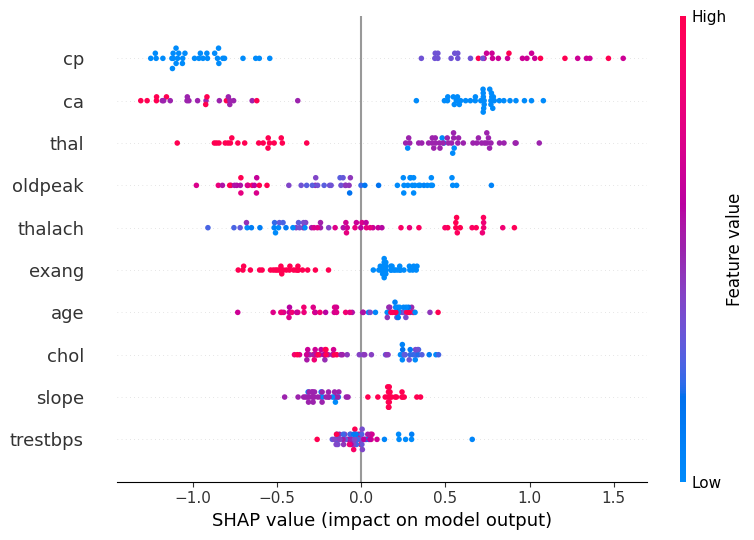

In [80]:
shap.summary_plot(
    shap_values,
    X_test_sel_scaled
)

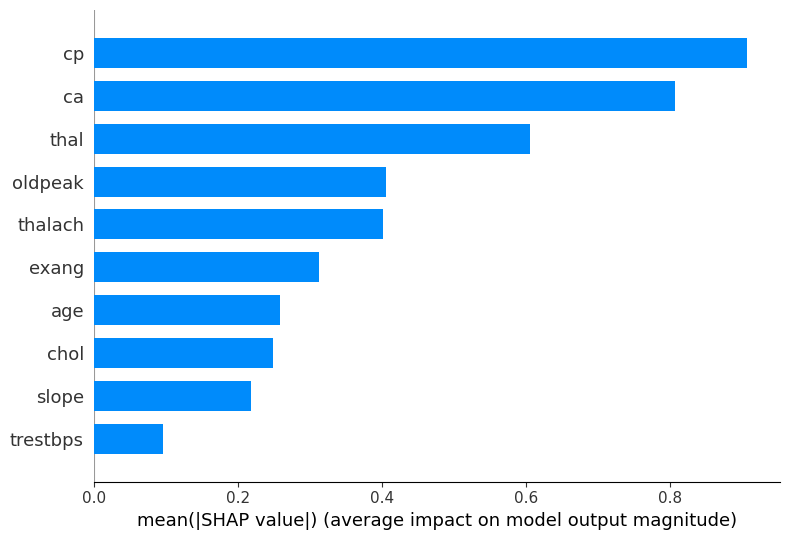

In [81]:
shap.summary_plot(
    shap_values,
    X_test_sel_scaled,
    plot_type="bar"
)

## C.6 Final Model Comparison

This section compares the performance of different approaches:

1. Original paper reported performance
2. Reproduced stacking ensemble using the full dataset
3. Duplicate-free stacking baseline
4. Proposed optimised stacking framework

The comparison highlights the impact of duplicate handling, feature selection, and hyperparameter optimisation.

In [82]:
# Final comparison table

final_comparison = pd.DataFrame({

    "Method": [
        "Original Paper Stacking",
        "Reproduced Stacking (1025 Records)",
        "Duplicate-Free Stacking (302 Records)",
        "Proposed Optimised Stacking"
    ],

    "Dataset": [
        "Original Dataset",
        "Original Dataset",
        "Unique Dataset",
        "Unique Dataset"
    ],

    "Accuracy": [
        0.9853,
        stacking_result["Accuracy"],
        stacking_unique_result["Accuracy"],
        optimized_result["Accuracy"]
    ],

    "Precision": [
        None,
        stacking_result["Precision"],
        stacking_unique_result["Precision"],
        optimized_result["Precision"]
    ],

    "Recall": [
        None,
        stacking_result["Recall"],
        stacking_unique_result["Recall"],
        optimized_result["Recall"]
    ],

    "F1 Score": [
        None,
        stacking_result["F1 Score"],
        stacking_unique_result["F1 Score"],
        optimized_result["F1 Score"]
    ],

    "AUC": [
        None,
        stacking_result["AUC"],
        stacking_unique_result["AUC"],
        optimized_result["AUC"]
    ]

})


final_comparison

,Method,Dataset,Accuracy,Precision,Recall,F1 Score,AUC
0,Original Paper Stacking,Original Dataset,0.985300,NaN,NaN,NaN,NaN
1,Reproduced Stacking (1025 Records),Original Dataset,1.000000,1.000000,1.000000,1.000000,1.000000
2,Duplicate-Free Stacking (302 Records),Unique Dataset,0.754098,0.764706,0.787879,0.776119,0.867965
3,Proposed Optimised Stacking,Unique Dataset,0.819672,0.805556,0.878788,0.840580,0.885281


In [83]:
# Percentage format for reporting

final_comparison_percentage = final_comparison.copy()


metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "AUC"
]


for col in metric_columns:

    final_comparison_percentage[col] = (
        final_comparison_percentage[col] * 100
    ).round(2)


final_comparison_percentage

,Method,Dataset,Accuracy,Precision,Recall,F1 Score,AUC
0,Original Paper Stacking,Original Dataset,98.53,NaN,NaN,NaN,NaN
1,Reproduced Stacking (1025 Records),Original Dataset,100.00,100.00,100.00,100.00,100.00
2,Duplicate-Free Stacking (302 Records),Unique Dataset,75.41,76.47,78.79,77.61,86.80
3,Proposed Optimised Stacking,Unique Dataset,81.97,80.56,87.88,84.06,88.53


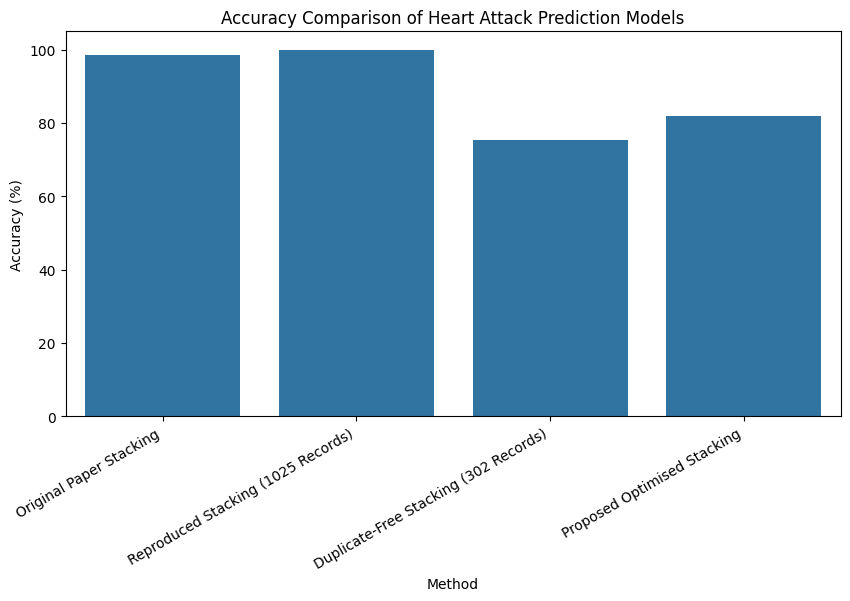

In [84]:
plt.figure(figsize=(10,5))


sns.barplot(
    data=final_comparison_percentage,
    x="Method",
    y="Accuracy"
)


plt.xticks(
    rotation=30,
    ha="right"
)


plt.title(
    "Accuracy Comparison of Heart Attack Prediction Models"
)


plt.ylabel(
    "Accuracy (%)"
)


plt.show()

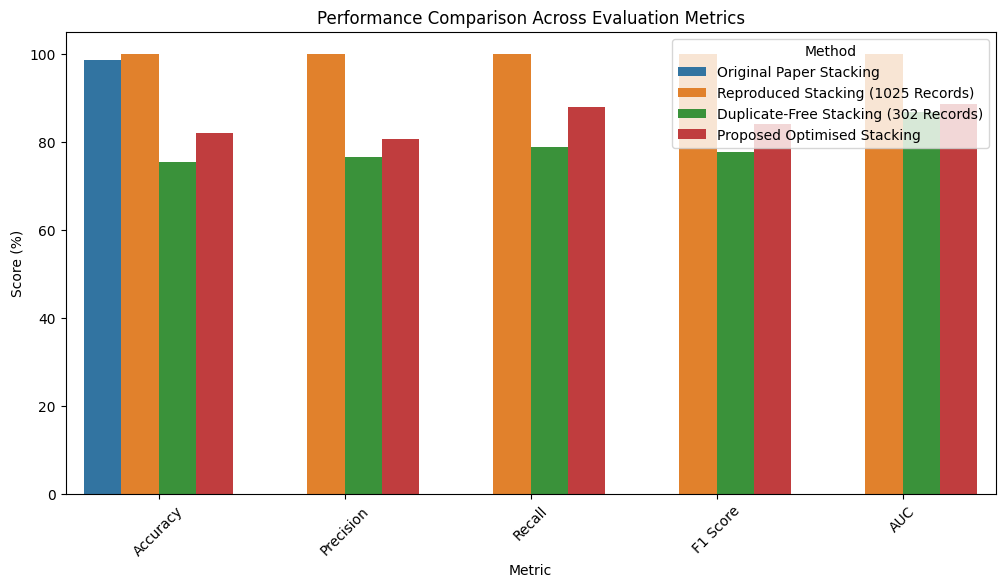

In [85]:
# Compare evaluation metrics

metrics_plot = final_comparison_percentage.melt(
    id_vars=["Method"],
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ],
    var_name="Metric",
    value_name="Score"
)


plt.figure(figsize=(12,6))


sns.barplot(
    data=metrics_plot,
    x="Metric",
    y="Score",
    hue="Method"
)


plt.title(
    "Performance Comparison Across Evaluation Metrics"
)


plt.ylabel(
    "Score (%)"
)


plt.xticks(rotation=45)

plt.show()

## C.7 Confusion Matrix Analysis

Confusion matrices are generated to evaluate classification performance beyond overall accuracy.

The analysis compares the duplicate-free baseline stacking model with the proposed optimised stacking framework.

The confusion matrix provides insight into:
- Correct predictions
- False alarms
- Missed heart disease cases

In [86]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Confusion matrix libraries imported")

Confusion matrix libraries imported


In [87]:
# Predictions from duplicate-free stacking model

y_pred_baseline = stacking_model_unique.predict(
    X_test_u_scaled
)


cm_baseline = confusion_matrix(
    y_test_u,
    y_pred_baseline
)


cm_baseline

array([[20,  8],
       [ 7, 26]])

<Figure size 500x400 with 0 Axes>

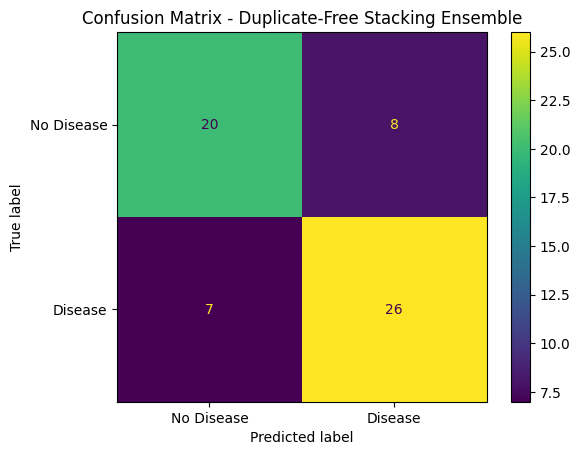

In [88]:
plt.figure(figsize=(5,4))


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=["No Disease", "Disease"]
)


disp.plot()


plt.title(
    "Confusion Matrix - Duplicate-Free Stacking Ensemble"
)


plt.show()

In [89]:
# Predictions from proposed optimized stacking model

y_pred_optimized = optimized_stacking_model.predict(
    X_test_sel_scaled
)


cm_optimized = confusion_matrix(
    y_test_sel,
    y_pred_optimized
)


cm_optimized

array([[21,  7],
       [ 4, 29]])

<Figure size 500x400 with 0 Axes>

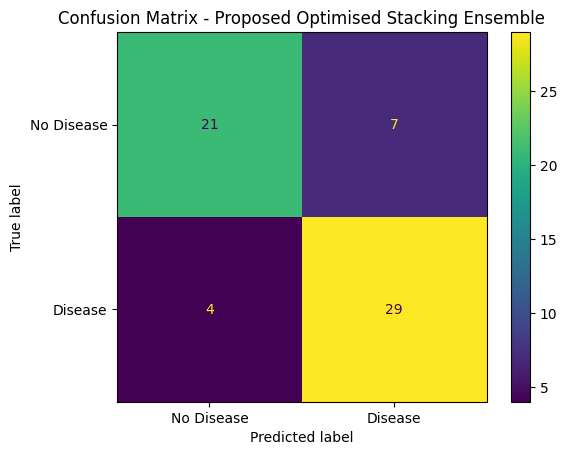

In [90]:
plt.figure(figsize=(5,4))


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_optimized,
    display_labels=["No Disease", "Disease"]
)


disp.plot()


plt.title(
    "Confusion Matrix - Proposed Optimised Stacking Ensemble"
)


plt.show()

## C.8 ROC Curve Analysis

Receiver Operating Characteristic (ROC) curves are generated to compare the classification performance of the duplicate-free baseline stacking model and the proposed optimised stacking framework.

The Area Under the Curve (AUC) is used as a summary measure of model discrimination performance.

In [91]:
from sklearn.metrics import roc_curve, auc

print("ROC libraries imported")

ROC libraries imported


In [92]:
# Baseline stacking probability predictions

y_prob_baseline = stacking_model_unique.predict_proba(
    X_test_u_scaled
)[:,1]


fpr_baseline, tpr_baseline, _ = roc_curve(
    y_test_u,
    y_prob_baseline
)


auc_baseline = auc(
    fpr_baseline,
    tpr_baseline
)


print("Baseline AUC:", auc_baseline)

Baseline AUC: 0.8679653679653679


In [93]:
# Proposed optimized stacking probability predictions

y_prob_optimized = optimized_stacking_model.predict_proba(
    X_test_sel_scaled
)[:,1]


fpr_optimized, tpr_optimized, _ = roc_curve(
    y_test_sel,
    y_prob_optimized
)


auc_optimized = auc(
    fpr_optimized,
    tpr_optimized
)


print("Optimised Model AUC:", auc_optimized)

Optimised Model AUC: 0.8852813852813853


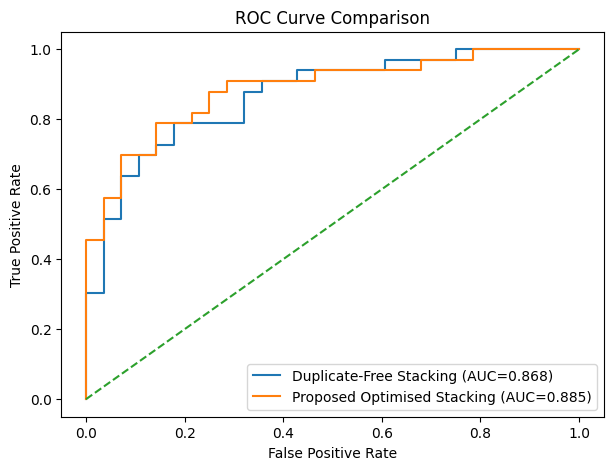

In [94]:
plt.figure(figsize=(7,5))


plt.plot(
    fpr_baseline,
    tpr_baseline,
    label=f"Duplicate-Free Stacking (AUC={auc_baseline:.3f})"
)


plt.plot(
    fpr_optimized,
    tpr_optimized,
    label=f"Proposed Optimised Stacking (AUC={auc_optimized:.3f})"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve Comparison"
)


plt.legend()

plt.show()

In [95]:
roc_comparison = pd.DataFrame({

    "Model": [
        "Duplicate-Free Stacking Ensemble",
        "Proposed Optimised Stacking Ensemble"
    ],

    "AUC": [
        auc_baseline,
        auc_optimized
    ]

})


roc_comparison

,Model,AUC
0,Duplicate-Free Stacking Ensemble,0.867965
1,Proposed Optimised Stacking Ensemble,0.885281


# Conclusion

This study successfully reproduced and evaluated a stacking-based ensemble framework for early heart attack prediction. The original dataset containing 1,025 records achieved extremely high performance during reproduction; however, further investigation identified 723 duplicate records, highlighting the potential risk of performance overestimation caused by duplicate observations.

After removing duplicate records, the model performance decreased, demonstrating the importance of reliable dataset validation in healthcare machine learning applications. To address this limitation, an improved framework was proposed by combining duplicate-aware evaluation, feature selection, and hyperparameter optimisation.

Random Forest feature importance analysis identified the most influential clinical predictors, and the top 10 features were selected for the proposed framework. Optimised Random Forest, XGBoost, and Logistic Regression models were integrated into a stacking ensemble approach. The proposed model achieved 81.97% accuracy, 84.06% F1-score, and 0.885 AUC on the unique patient dataset, outperforming the duplicate-free baseline model.

Furthermore, SHAP-based explainability analysis demonstrated that important clinical variables such as chest pain type, number of major vessels, thalassemia indicator, oldpeak, and maximum heart rate significantly influenced model predictions.

Overall, the proposed framework provides a more reliable and interpretable approach for heart attack prediction by addressing data quality issues and improving model transparency. The findings highlight the importance of combining robust evaluation, optimisation techniques, and explainable artificial intelligence for healthcare prediction systems.

# Generative AI Acknowledgement

Generative Artificial Intelligence (GenAI) tools were used during the development of this project to support coding assistance, debugging, documentation improvement, and explanation of machine learning concepts.

The use of GenAI was limited to assisting with:
- Understanding machine learning implementation approaches.
- Improving code structure and readability.
- Supporting troubleshooting during model development.
- Assisting with the organisation and presentation of experimental results.

All dataset processing, model training, evaluation, interpretation of results, and final conclusions were reviewed and validated by the author. The final submitted work represents the author's own understanding and implementation of the proposed machine learning framework.